In [1]:
# вычисление и визуализация
# численного решения краевой задачи (5.84)
# ДУ (5.76) с правой частью (5.83)

# Ячейка № 1

# подключение библиотеки numpy
import numpy as np

# подключение библиотеки matplotlib.pyplot
import matplotlib.pyplot as plt


In [ ]:
# Ячейка № 2

# задание функции, возвращающей:
# х - массив, содержащий координаты узлов,
# в которых ищется решение краевой задачи (5.84)
# ДУ (5.76) с правой частью (5.83);
# phi - массив, содержащий численное решение краевой задачи,
# вычисленных на каждом шаге итерационного процесса;
# En - массив, содержащий энергию решений краевой задачи


def Iteration(N, Omega, Number_of_Iteration):
    # входные параметры:
    # N - число узлов сетки
    # Omega - параметр разностной схемы (см. (5.81))
    # Number_of_Iteration - число итераций

    # задание координат узлов
    x = np.linspace(0, 1, N)

    # вычисление шага выбранной сетки
    h = x[1] - x[0]

    # инициализация массива, используемого
    # для хранения значений начального приближения
    # решения краевой задачи
    f = np.zeros(N)

    # вычисление значений функции,
    # использованной в качестве начального приближения
    for i in range(N):
        f[i] = 12 * x[i] ** 2

    # инициализация массива, используемого для
    # хранения решений краевой задачи,
    # вычисленных на соответствующей итерации
    phi = np.zeros([Number_of_Iteration, N])

    # инициализация массива, используемого для
    # хранения функционала энергии решений краевой задачи,
    # вычисленных на соответствующей итерации
    En = np.zeros(Number_of_Iteration - 1)

    # вычисление решений краевой задачи и их энергий
    for j in range(Number_of_Iteration - 1):
        # вычисление текущего решения краевой задачи
        for i in range(N - 2):
            phi[j + 1, i + 1] = (1 - Omega) * phi[j, i + 1] + Omega / 2 * (
                phi[j, i + 2] + phi[j, i] + h**2 * f[i + 1]
            )

        # вычисление энергии текущего решения краевой задачи
        E = 0
        for i in range(N - 1):
            E = (
                E
                + ((phi[j + 1, i + 1] - phi[j + 1, i]) ** 2) / (2 * h)
                - h * phi[j + 1, i + 1] * f[i + 1]
            )
        En[j] = E
    return x, phi, En

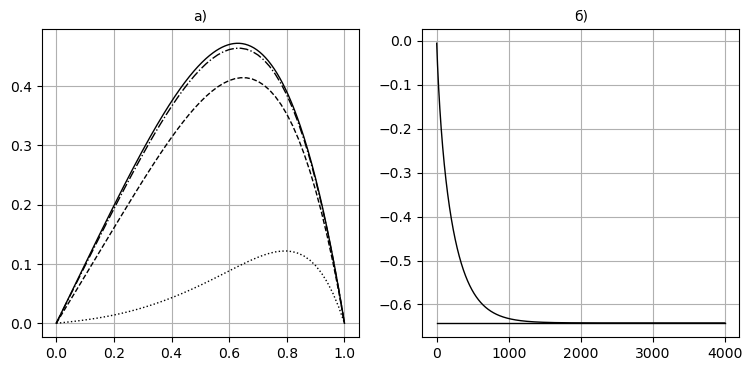

In [3]:
# Ячейка № 3

# задание числа узлов сетки
N = 51

# задание значения параметра Omega в (5.78)
Omega = 1

# задание числа итераций
Ni = 4000

# вычисление решения краевой задачи
x, y, En = Iteration(N, Omega, Ni)

# вычисление значений функции,
# являющейся точным решением краевой задачи
N1 = 300
x1 = np.linspace(0, 1, N1)
y1 = np.zeros(N1)
for i in range(N1):
    y1[i] = x1[i] * (1 - x1[i] ** 3)

# визуализация точного и выбранного
# решений краевой задачи и зависимости
# от номера итерации
fig = plt.figure(figsize=(9, 4))

ax = fig.add_subplot(1, 2, 1)
ax.plot(x1, y1, "-k", lw=1)
ax.plot(x, y[100, :], ":k", lw=1)
ax.plot(x, y[1000, :], "--k", lw=1)
ax.plot(x, y[2000, :], "-.k", lw=1)
ax.grid(True)
plt.title(r"а)", fontsize=10)

ax = fig.add_subplot(1, 2, 2)
ax.plot(En, "-k", lw=1)
ax.plot([0, Ni], [-9 / 14, -9 / 14], "-k", lw=1)
ax.grid(True)
plt.title(r"б)", fontsize=10)

plt.show()